# Financial Sentinel: Credit Card Fraud Detection using Machine Learning

## Project Overview

Financial fraud has become one of the most significant challenges in the digital payment ecosystem. Even a small percentage of fraudulent transactions can result in substantial financial losses for banks, payment processors, and customers.

This project focuses on building a machine learning pipeline capable of distinguishing fraudulent credit card transactions from legitimate ones using anonymized transaction data.

The dataset contains transactions made by European cardholders over two days and is characterized by an extremely imbalanced class distribution, making fraud detection a challenging binary classification problem.

---

## Problem Statement

Develop a machine learning solution capable of accurately identifying fraudulent credit card transactions while minimizing false negatives and maintaining a low false positive rate. The primary challenge lies in the extreme class imbalance, where fraudulent transactions represent less than 0.2% of the total observations.

---

## Objectives

The primary objectives of this project are:

- Understand the characteristics of the dataset through Exploratory Data Analysis (EDA)
- Assess data quality and identify potential preprocessing requirements
- Analyze the severe class imbalance present in the dataset
- Explore feature distributions and relationships
- Build an intuition for selecting appropriate preprocessing techniques and machine learning models

---

## Dataset Information

The dataset used in this project is the **Credit Card Fraud Detection** dataset.

### Dataset Characteristics

| Property | Value |
|----------|--------|
| Total Transactions | 284,807 |
| Fraudulent Transactions | 492 |
| Legitimate Transactions | 284,315 |
| Features | 30 |
| Target Variable | Class |
| Problem Type | Binary Classification |

### Feature Description

- **Time** — Seconds elapsed between each transaction and the first transaction in the dataset.
- **Amount** — Transaction amount.
- **V1–V28** — Anonymized numerical features generated using Principal Component Analysis (PCA).
- **Class**
  - **0** → Legitimate transaction
  - **1** → Fraudulent transaction

> **Note:** The original transaction features were transformed using PCA to protect customer confidentiality. Consequently, the semantic meaning of features V1–V28 is unavailable.

---

## Notebook Scope

This notebook presents an end-to-end machine learning workflow for credit card fraud detection. The analysis progresses from understanding the dataset through exploratory analysis to building, evaluating, and comparing machine learning models before demonstrating inference on unseen transactions.

The notebook is organized into clearly defined sections, allowing each stage of the workflow to build naturally upon the previous one.

## Project Workflow

The analysis follows the standard machine learning workflow:

1. Dataset Loading
2. Dataset Overview
3. Data Quality Assessment
4. Exploratory Data Analysis
5. Data Preprocessing
6. Model Development
7. Model Evaluation
8. Model Comparison
9. Model Serialization
10. Inference on New Transactions

## Import Libraries and Notebook Configuration

This section imports all required libraries and configures the notebook environment to ensure consistent visualization, reproducibility, and output formatting throughout the analysis.

In [1]:
# Standard Library
from pathlib import Path
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from imblearn.over_sampling import SMOTE

# Model Persistence
import joblib

In [2]:
# Notebook Configuration
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "data" / "creditcard.csv"

df = pd.read_csv(DATASET_PATH)

In [4]:
print("DATASET OVERVIEW")

print(f"Number of Transactions : {df.shape[0]:,}")
print(f"Number of Features     : {df.shape[1]-1}")
print(f"Target Variable        : Class")

DATASET OVERVIEW
Number of Transactions : 284,807
Number of Features     : 30
Target Variable        : Class


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [8]:
df["Class"].value_counts().rename(index={
    0: "Legitimate",
    1: "Fraudulent"
}).to_frame("Count")

,Count
Class,
Legitimate,284315
Fraudulent,492


In [9]:
pca_features = [col for col in df.columns if col.startswith("V")]

print(f"Original Features      : ['Time', 'Amount']")
print(f"Number of PCA Features : {len(pca_features)}")
print(f"PCA Features           : {', '.join(pca_features)}")

Original Features      : ['Time', 'Amount']
Number of PCA Features : 28
PCA Features           : V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28


### Initial Observations

- The dataset contains 284,807 transactions and 30 predictor variables.
- Features V1–V28 are anonymized principal components generated using PCA.
- Time and Amount retain their original meaning.
- The target variable is binary, representing legitimate and fraudulent transactions.
- All predictor variables are numerical, making the dataset well suited for machine learning algorithms without categorical encoding.

# 4. Data Quality Assessment

Before exploring patterns in the data, it is essential to assess its quality and integrity. This section evaluates the dataset for common issues that can affect machine learning models, including missing values, duplicate records, and data type consistency.

The objective is to identify potential problems without making any modifications to the dataset at this stage.

In [10]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().mean() * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage (%)
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0


In [11]:
if missing_summary["Missing Values"].sum() == 0:
    print("No missing values found.")
else:
    print("Missing values detected.")

No missing values found.


In [12]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Transactions : {duplicate_count:,}")
print(f"Percentage of Dataset  : {duplicate_percentage:.2f}%")

Duplicate Transactions : 1,081
Percentage of Dataset  : 0.38%


In [13]:
dtype_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.count(),
    "Unique Values": df.nunique()
})

dtype_summary

,Data Type,Non-Null Count,Unique Values
Time,float64,284807,124592
V1,float64,284807,275663
V2,float64,284807,275663
V3,float64,284807,275663
V4,float64,284807,275663
V5,float64,284807,275663
V6,float64,284807,275663
V7,float64,284807,275663
V8,float64,284807,275663
V9,float64,284807,275663


### Data Quality Summary

The dataset demonstrates a high level of data quality and requires minimal cleaning prior to model development.

Key observations:

- No missing values were detected in any feature.
- A total of **1,081 duplicate transactions** (**0.38%** of the dataset) were identified.
- Duplicate records have been retained at this stage because identical transactions may represent genuine repeated purchases or repeated fraudulent activities.
- All predictor variables are numerical, eliminating the need for categorical encoding.
- The target variable is binary and suitable for supervised classification.

Overall, the dataset is well-prepared for exploratory analysis and subsequent model development.

# 5. Class Imbalance Analysis

Fraud detection is inherently an imbalanced classification problem, where fraudulent transactions constitute only a tiny fraction of all observations.

Understanding the severity of this imbalance is essential because it directly influences model selection, evaluation metrics, and preprocessing techniques. A model trained on such data can easily achieve high accuracy by predicting every transaction as legitimate while completely failing to identify fraudulent transactions.

This section quantifies the class imbalance and discusses its implications for model development.

In [14]:
class_counts = df["Class"].value_counts().sort_index()

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages.round(4)
})

class_summary.index = ["Legitimate", "Fraudulent"]

class_summary

,Count,Percentage (%)
Legitimate,284315,99.8273
Fraudulent,492,0.1727


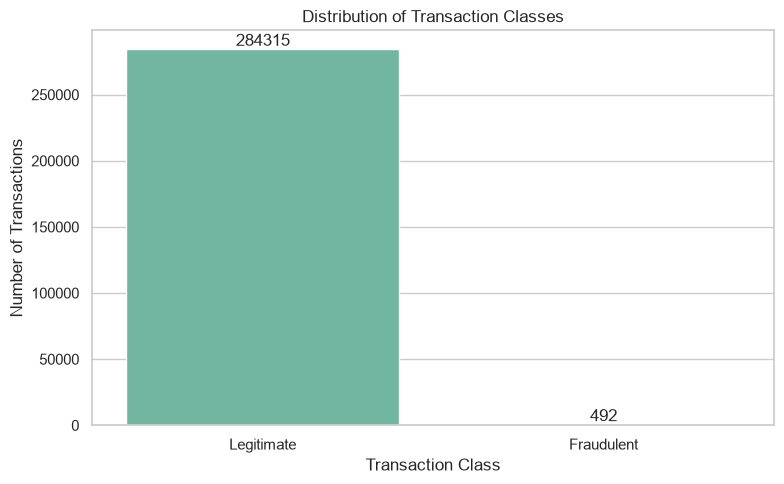

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Transaction Classes")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

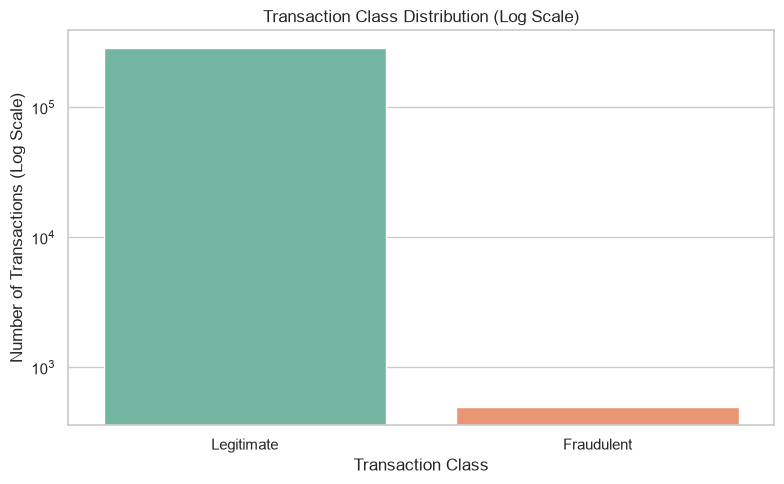

In [16]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Class",
    hue="Class",
    palette="Set2",
    legend=False
)

plt.yscale("log")

plt.title("Transaction Class Distribution (Log Scale)")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions (Log Scale)")

plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.tight_layout()
plt.show()

# 6. Univariate Analysis

This section examines the distributions of the original transaction features: **Time** and **Amount**.

Unlike the anonymized PCA features (V1–V28), these variables retain their original meaning and can provide valuable insights into transaction behavior, temporal patterns, and monetary distributions.

## 6.1 Transaction Amount Distribution

In [17]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

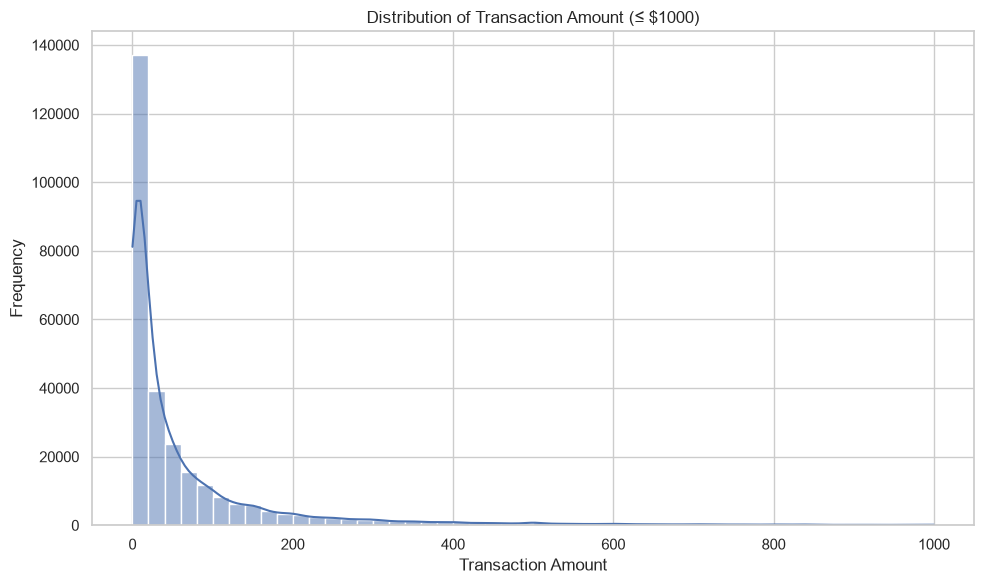

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df[df["Amount"] <= 1000]["Amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount (≤ $1000)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

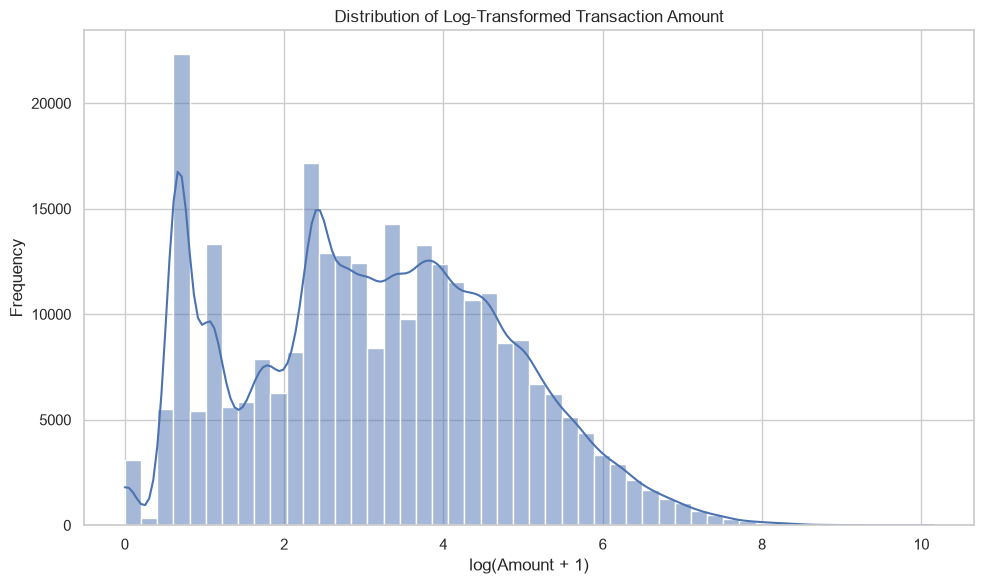

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

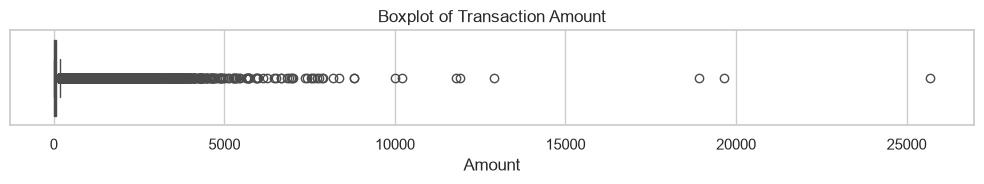

In [20]:
plt.figure(figsize=(10, 2))

sns.boxplot(
    x=df["Amount"]
)

plt.title("Boxplot of Transaction Amount")

plt.tight_layout()
plt.show()

### Interpretation

The transaction amount distribution is **highly positively skewed**.

**Key observations:**

- The median transaction amount is **22.00**, while the mean is **88.35**, indicating that a relatively small number of high-value transactions increase the average transaction amount.
- Approximately **75%** of transactions are below **77.17**, showing that most transactions involve relatively small amounts.
- The histogram demonstrates that the majority of transactions are concentrated below **1,000**, while the boxplot confirms the presence of several extreme outliers exceeding **25,000**.
- These characteristics indicate that the distribution is non-normal and heavily right-skewed.

From a modeling perspective, the **Amount** feature will be standardized before training algorithms such as **Logistic Regression** to ensure that its scale does not dominate the learning process.

## 6.2 Transaction Time Distribution

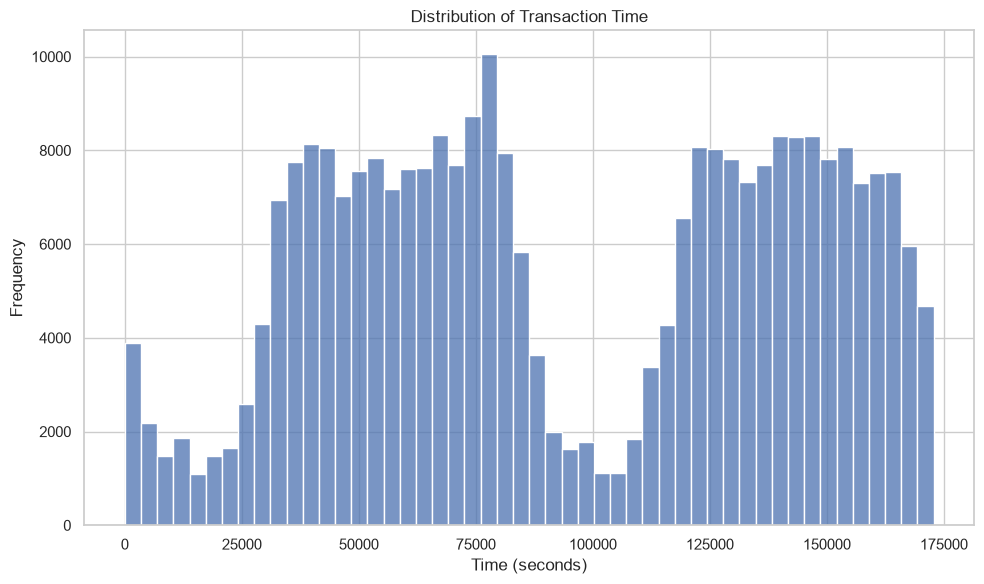

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Time"],
    bins=50,
)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The **Time** feature represents the number of seconds elapsed since the first recorded transaction rather than the actual clock time.

Key observations:

- The transaction volume varies throughout the observation period rather than remaining uniform.
- Two prominent peaks in transaction activity are visible, separated by periods of lower activity. Since the dataset spans approximately two days, this pattern is consistent with daily fluctuations in transaction volume.
- The **Time** feature alone does not reveal the exact hour or date of a transaction because the original timestamps were anonymized.

From a modeling perspective, the **Time** feature may still contain predictive information. It will be retained during model development and standardized alongside the **Amount** feature before training models such as Logistic Regression.

# 6. Comparative Analysis: Legitimate vs Fraudulent Transactions

After understanding the overall characteristics of the dataset, the next step is to compare legitimate and fraudulent transactions.

This analysis focuses on identifying differences in transaction amount and other key characteristics that may help machine learning models distinguish fraudulent transactions from legitimate ones.

In [22]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


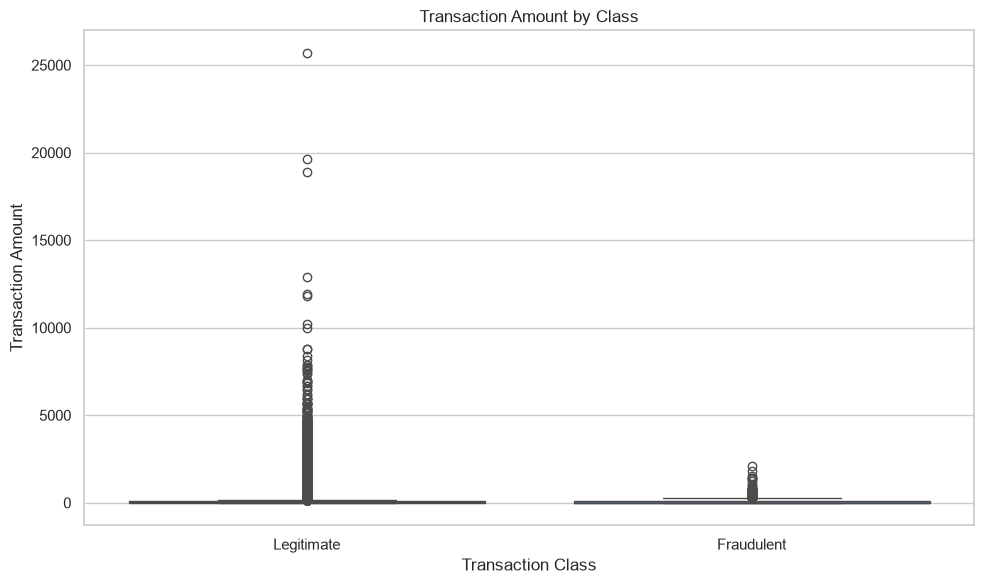

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks([0,1],["Legitimate","Fraudulent"])

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

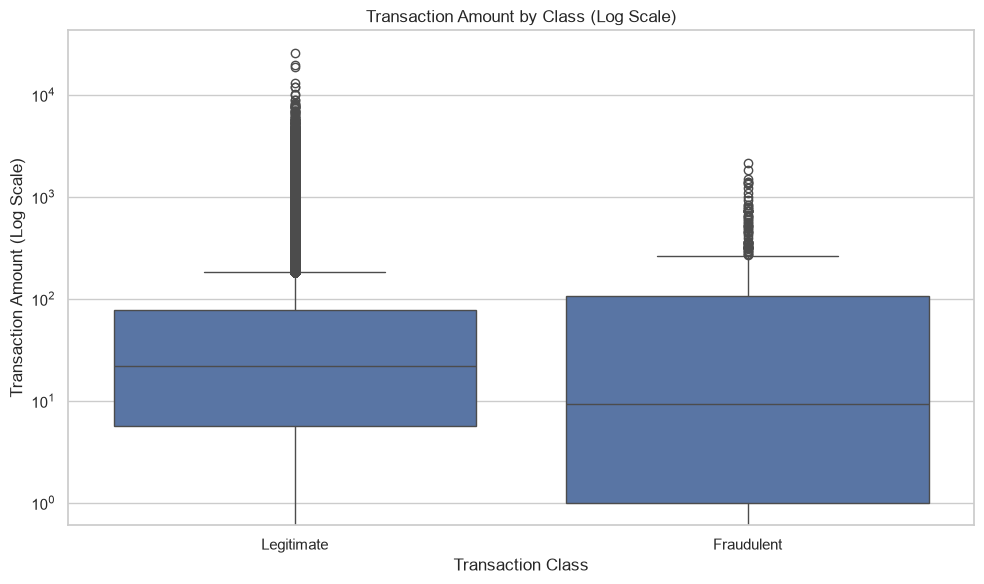

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.xticks([0,1],["Legitimate","Fraudulent"])

plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount (Log Scale)")

plt.tight_layout()
plt.show()

### Interpretation

Comparing transaction amounts across the two classes reveals that transaction amount alone is not a strong discriminator of fraudulent activity.

**Key observations:**

- Fraudulent transactions exhibit a higher **mean** transaction amount (**122.21**) than legitimate transactions (**88.29**), suggesting that some fraudulent transactions involve relatively large amounts.
- However, the **median** transaction amount for fraudulent transactions (**9.25**) is lower than that of legitimate transactions (**22.00**), indicating that many fraud cases also involve small-value transactions.
- Both classes contain substantial variability and numerous outliers, resulting in considerable overlap between their distributions.
- The log-scale boxplot highlights this overlap more clearly while reducing the visual impact of extreme values.

Overall, **Amount alone cannot reliably distinguish fraudulent transactions from legitimate ones**. It should therefore be used in combination with the anonymized PCA features during model development.

# 7. Correlation Analysis

Correlation analysis helps identify linear relationships between features and the target variable. Although correlation alone does not imply causation, it provides valuable insights into which features may be most informative for fraud detection.

Since most predictor variables are anonymized principal components (V1–V28), correlation analysis serves as one of the few interpretable methods for assessing their relationship with fraudulent transactions.

In [25]:
corr_matrix = df.corr(numeric_only=True)

In [26]:
target_corr = (
    corr_matrix["Class"]
    .drop("Class")
    .sort_values()
)

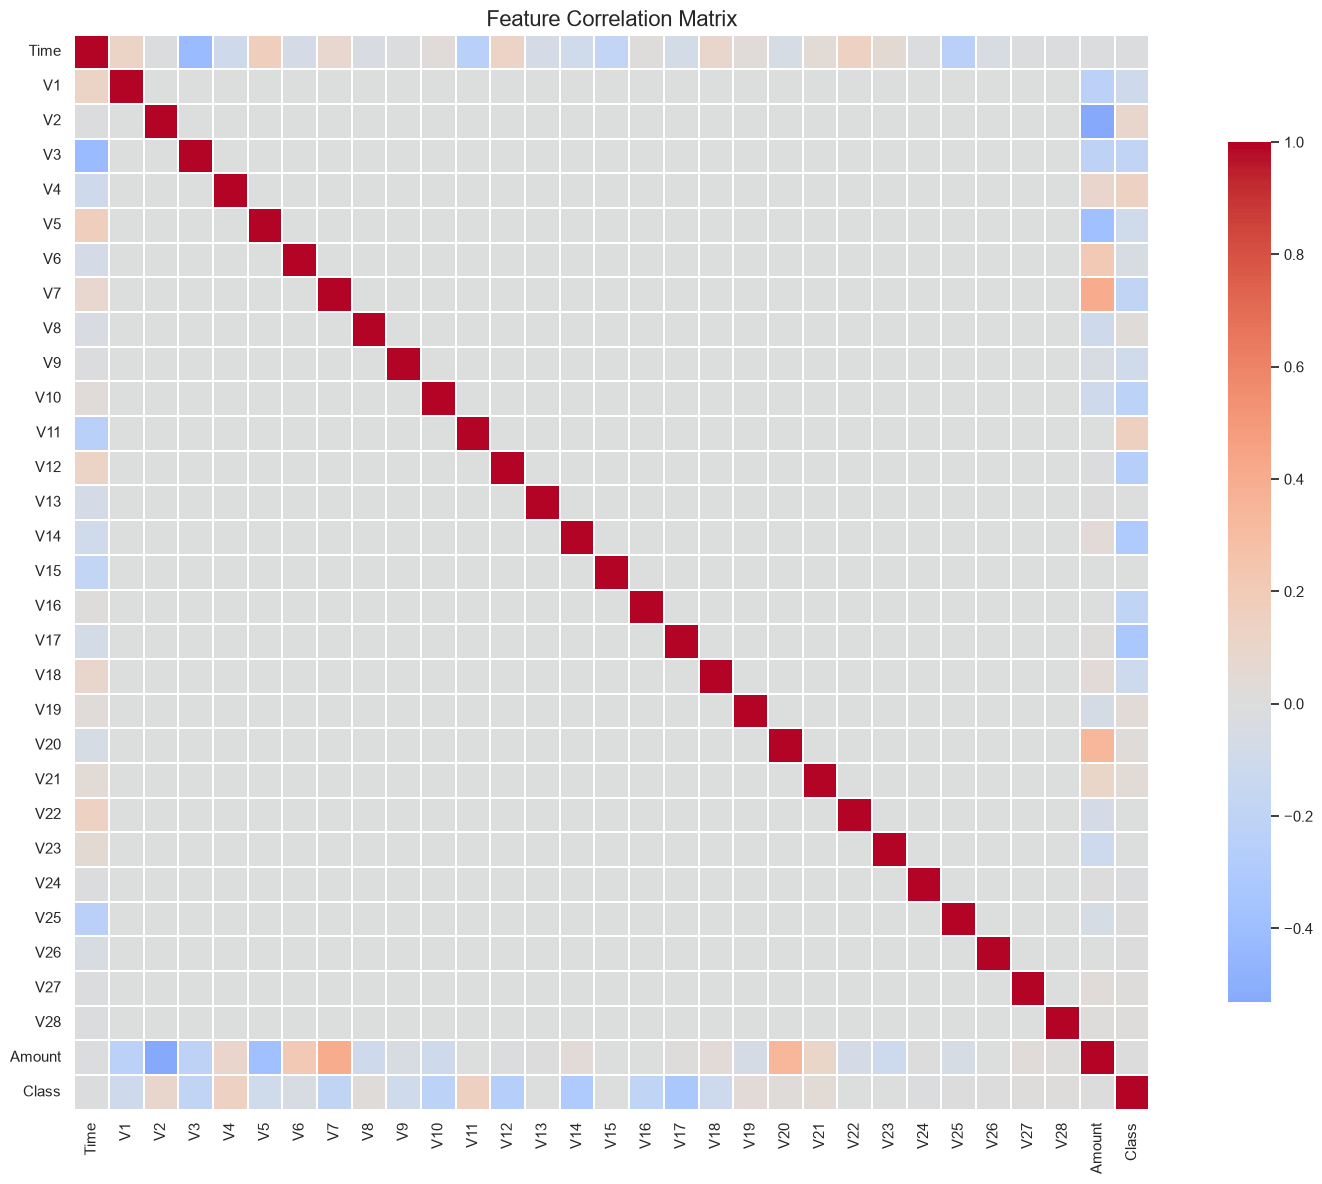

In [27]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Feature Correlation Matrix", fontsize=16)

plt.tight_layout()
plt.show()

In [28]:
top_positive = (
    target_corr
    .nlargest(10)
    .to_frame("Correlation")
)

top_negative = (
    target_corr
    .nsmallest(10)
    .to_frame("Correlation")
)

print("Top Positive Correlations with Fraud")
display(top_positive)

print("Top Negative Correlations with Fraud")
display(top_negative)

Top Positive Correlations with Fraud


,Correlation
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536
Amount,0.005632


Top Negative Correlations with Fraud


,Correlation
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


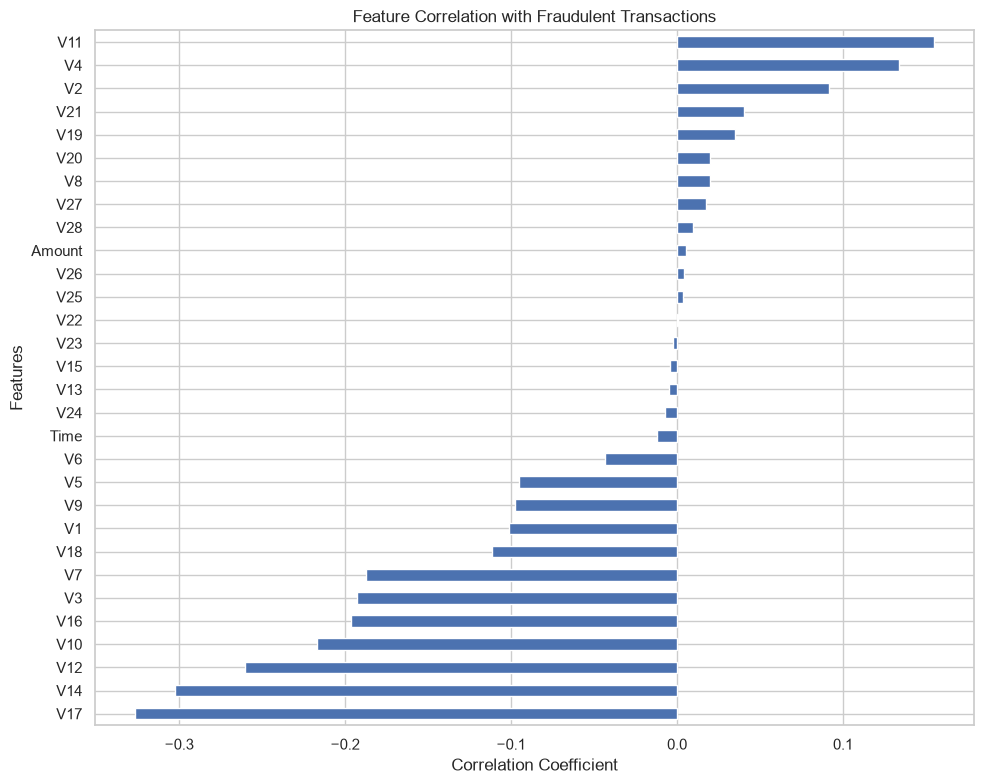

In [29]:
plt.figure(figsize=(10,8))

target_corr.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Fraudulent Transactions")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

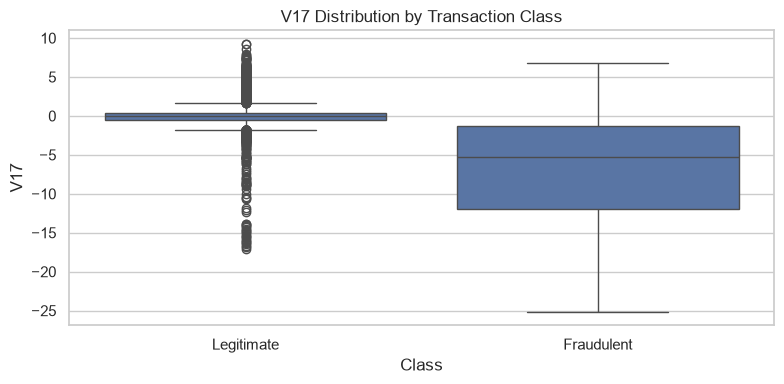

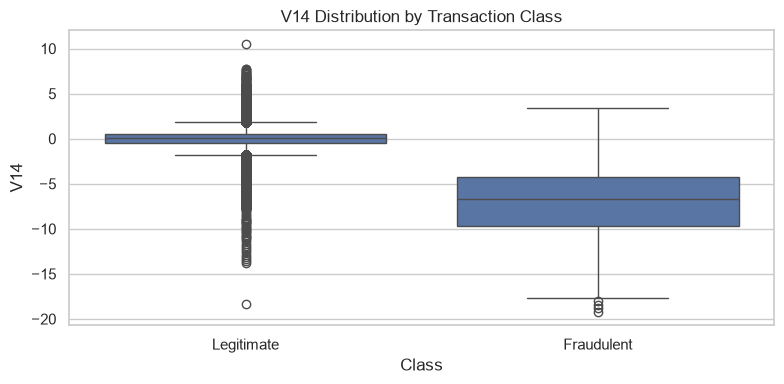

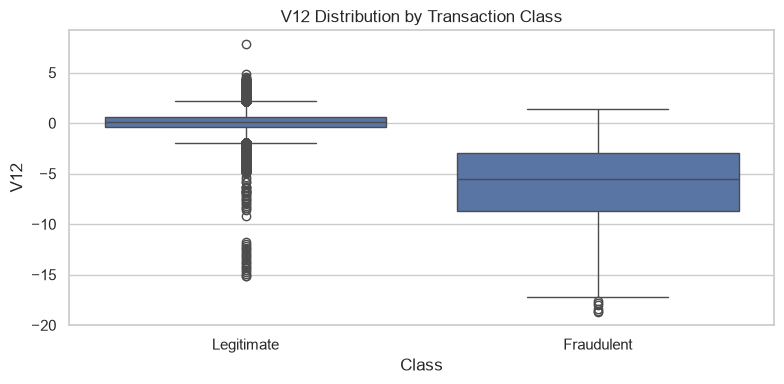

In [30]:
features = ["V17", "V14", "V12"]

for feature in features:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.xticks([0,1],["Legitimate","Fraudulent"])
    plt.title(f"{feature} Distribution by Transaction Class")

    plt.tight_layout()
    plt.show()

### Interpretation

Correlation analysis indicates that several anonymized PCA features exhibit meaningful linear relationships with fraudulent transactions.

**Key observations:**

- **V11**, **V4**, and **V2** show the strongest positive correlations with the target variable, indicating that higher values of these transformed features are associated with an increased likelihood of fraud.
- **V17**, **V14**, and **V12** exhibit the strongest negative correlations, suggesting an inverse relationship with fraudulent transactions.
- The original **Time** and **Amount** features show only very weak correlations with the target variable, indicating that they provide limited discriminatory power on their own.
- Although several PCA features display moderate correlations with the target, no individual feature is sufficiently predictive in isolation. Effective fraud detection therefore relies on learning complex relationships among multiple variables.

Overall, the anonymized PCA features appear to contain substantially more predictive information than the original transaction features, supporting the use of machine learning models capable of combining information across many features.

# 8. Data Preprocessing

Before training machine learning models, the dataset must be prepared appropriately.

The preprocessing pipeline consists of:

- Separating features and the target variable.
- Splitting the dataset into training and testing sets.
- Standardizing numerical features.
- Handling class imbalance using SMOTE on the training data.

In [31]:
X = df.drop(columns="Class")
y = df["Class"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Feature Matrix Shape : (284807, 30)
Target Vector Shape  : (284807,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

Training Features : (227845, 30)
Testing Features  : (56962, 30)
Training Labels   : (227845,)
Testing Labels    : (56962,)


### Feature Standardization

The **Time** and **Amount** features have significantly different scales from the PCA-transformed features.

To ensure fair contribution of all features during optimization, the training data was standardized using **StandardScaler**. The scaler was fitted exclusively on the training data and then applied to the test data, preventing information leakage.

In [33]:
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [34]:
# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [35]:
balanced_summary = (
    pd.Series(y_train_balanced)
      .value_counts()
      .rename(index={0:"Legitimate",1:"Fraudulent"})
      .to_frame("Count")
)

balanced_summary

,Count
Class,
Legitimate,227451
Fraudulent,227451


In [36]:
shape_summary = pd.DataFrame({
    "Dataset":[
        "Training (Original)",
        "Training (Balanced)",
        "Testing"
    ],
    "Samples":[
        X_train.shape[0],
        X_train_balanced.shape[0],
        X_test.shape[0]
    ],
    "Features":[
        X_train.shape[1],
        X_train_balanced.shape[1],
        X_test.shape[1]
    ]
})

shape_summary

,Dataset,Samples,Features
0,Training (Original),227845,30
1,Training (Balanced),454902,30
2,Testing,56962,30


### Why SMOTE?

The original training data is highly imbalanced, with fraudulent transactions representing less than **0.2%** of all observations.

Training directly on such data can bias many machine learning algorithms toward predicting the majority class.

To address this issue, **Synthetic Minority Oversampling Technique (SMOTE)** was applied exclusively to the training data. SMOTE generates synthetic minority-class samples rather than duplicating existing observations, enabling models to learn more representative decision boundaries while preserving an unbiased test set for evaluation.

# 9. Model Development

To evaluate different modeling approaches, two complementary machine learning algorithms were selected.

- **Logistic Regression** serves as a strong baseline because it is simple, interpretable, and performs well on linearly separable classification problems.
- **Random Forest** was chosen as a non-linear ensemble model capable of capturing complex interactions among the anonymized PCA features.

These models were selected to compare the performance of a linear classifier with a tree-based ensemble while maintaining a balance between interpretability and predictive capability.

## 9.1 Logistic Regression

Logistic Regression was selected as the baseline model because it is computationally efficient, interpretable, and widely used for binary classification problems.

In [37]:
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(
    X_train_balanced,
    y_train_balanced
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [38]:
lr_predictions = logistic_model.predict(X_test_scaled)

lr_probabilities = logistic_model.predict_proba(X_test_scaled)[:,1]

## 9.2 Random Forest

Random Forest was selected because ensemble tree-based models often perform well on fraud detection tasks by capturing complex interactions between features while remaining relatively robust to noise and outliers.

In [39]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [40]:
rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:,1]

# 10. Model Evaluation

The trained models are evaluated on the unseen test dataset to assess their ability to distinguish fraudulent transactions from legitimate ones.

Given the severe class imbalance, multiple evaluation metrics are considered rather than relying solely on accuracy.

The following metrics are reported:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

These metrics provide a comprehensive assessment of model performance from both a general classification and fraud detection perspective.

In [41]:
def evaluate_model(model_name, y_true, y_pred, y_prob):

    print(model_name.upper())

    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

LOGISTIC REGRESSION
Accuracy  : 0.9741
Precision : 0.0578
Recall    : 0.9184
F1 Score  : 0.1088
ROC-AUC   : 0.9708

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



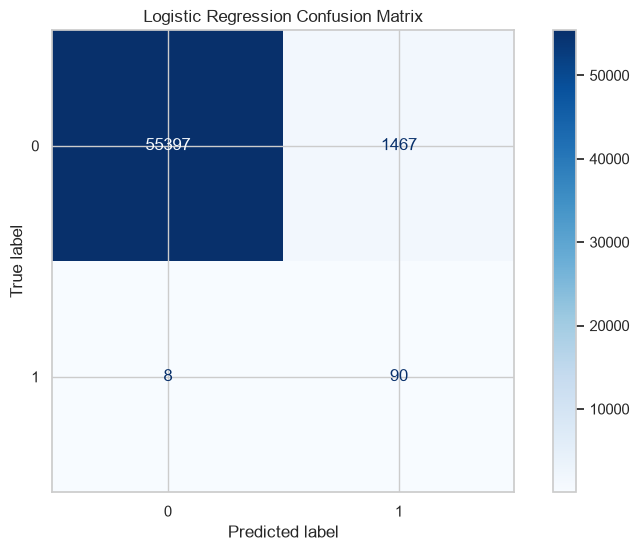

In [42]:
# Logistic Regression Evaluation
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions,
    lr_probabilities
)

RANDOM FOREST
Accuracy  : 0.9993
Precision : 0.8256
Recall    : 0.7245
F1 Score  : 0.7717
ROC-AUC   : 0.9669

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962



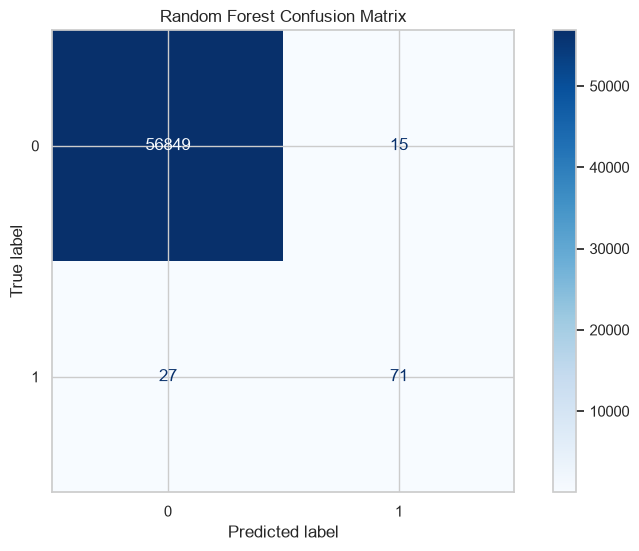

In [43]:
# Random Forest Evaluation
evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)

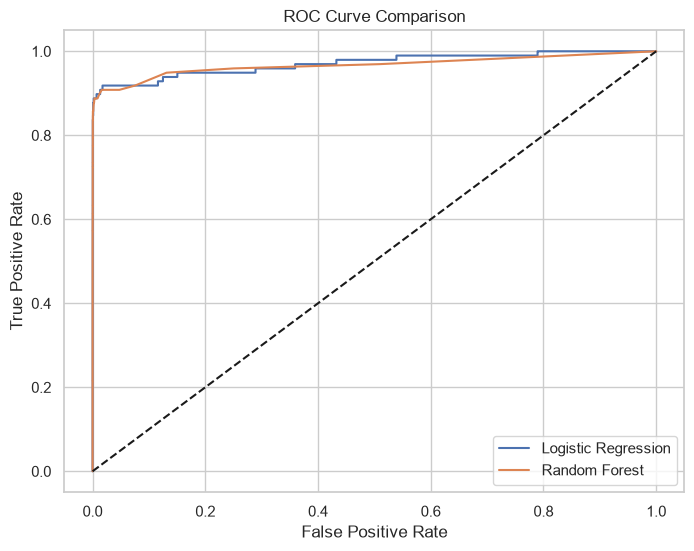

In [44]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

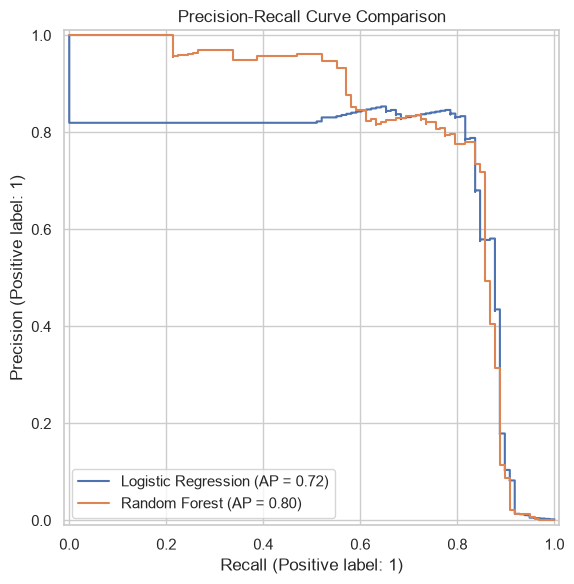

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    lr_probabilities,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest",
    ax=ax
)

ax.set_title("Precision-Recall Curve Comparison")

plt.tight_layout()
plt.show()

# 11. Model Comparison

To determine the most suitable model for credit card fraud detection, the performance of Logistic Regression and Random Forest is compared across multiple evaluation metrics.

Given the severe class imbalance, model selection is based not only on overall accuracy but also on precision, recall, F1-score, and ROC-AUC.

In [46]:
comparison = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, lr_predictions),
        precision_score(y_test, lr_predictions),
        recall_score(y_test, lr_predictions),
        f1_score(y_test, lr_predictions),
        roc_auc_score(y_test, lr_probabilities)
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_predictions),
        precision_score(y_test, rf_predictions),
        recall_score(y_test, rf_predictions),
        f1_score(y_test, rf_predictions),
        roc_auc_score(y_test, rf_probabilities)
    ]
})

display(
    comparison.style.format({
        "Logistic Regression": "{:.4f}",
        "Random Forest": "{:.4f}"
    })
)

,Evaluation Metric,Logistic Regression,Random Forest
0,Accuracy,0.9741,0.9993
1,Precision,0.0578,0.8256
2,Recall,0.9184,0.7245
3,F1-Score,0.1088,0.7717
4,ROC-AUC,0.9708,0.9669


# 12. Model Serialization

Once the final model has been selected, it is saved for future inference and deployment.

The trained Random Forest model and the fitted StandardScaler are serialized using the `joblib` library, allowing them to be loaded without retraining.

In [47]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(rf_model, MODEL_DIR / "random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [48]:
joblib.dump(scaler, MODEL_DIR / "standard_scaler.pkl")

print("StandardScaler saved successfully.")

StandardScaler saved successfully.


In [49]:
print("Saved Files:")

for file in MODEL_DIR.iterdir():
    print("-", file.name)

Saved Files:
- .ipynb_checkpoints
- random_forest_model.pkl
- standard_scaler.pkl


# 13. Conclusion

This project developed an end-to-end machine learning pipeline for detecting fraudulent credit card transactions.

The workflow included:

- Data quality assessment
- Exploratory data analysis
- Feature preprocessing
- Handling severe class imbalance using SMOTE
- Training and evaluating Logistic Regression and Random Forest models
- Comparing model performance using multiple evaluation metrics
- Saving the final model for deployment

Among the evaluated models, **Random Forest** achieved the best overall balance between precision, recall, and F1-score while maintaining excellent predictive performance. Consequently, it was selected as the final model for deployment.

Although Logistic Regression achieved a higher recall, its large number of false positives resulted in substantially lower precision. The comparison demonstrates the importance of selecting evaluation metrics based on the business requirements of fraud detection rather than relying solely on overall accuracy.

## Future Work

Several improvements could further enhance this project:

- Evaluate additional ensemble models such as XGBoost and LightGBM.
- Perform systematic hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Optimize the classification threshold based on business objectives rather than using the default probability threshold of 0.5.
- Incorporate feature importance analysis and model explainability techniques such as SHAP.
- Deploy the model as a REST API using FastAPI or Flask.
- Implement real-time fraud detection with continuous monitoring and periodic model retraining.

In [51]:
df[df["Class"] == 0].iloc[0]

Time        0.000000
V1         -1.359807
V2         -0.072781
V3          2.536347
V4          1.378155
V5         -0.338321
V6          0.462388
V7          0.239599
V8          0.098698
V9          0.363787
V10         0.090794
V11        -0.551600
V12        -0.617801
V13        -0.991390
V14        -0.311169
V15         1.468177
V16        -0.470401
V17         0.207971
V18         0.025791
V19         0.403993
V20         0.251412
V21        -0.018307
V22         0.277838
V23        -0.110474
V24         0.066928
V25         0.128539
V26        -0.189115
V27         0.133558
V28        -0.021053
Amount    149.620000
Class       0.000000
Name: 0, dtype: float64